In [120]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix
import joblib as jb
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [63]:
data = pd.read_csv('Resources/polynomial_regression_data.csv')
data.head()

,sno,Temperature,Pressure
0,1,0.000000,0.000000e+00
1,2,1.010101,2.061220e-10
2,3,2.020202,1.648976e-09
3,4,3.030303,5.565295e-09
4,5,4.040404,1.319181e-08


<Axes: xlabel='Temperature', ylabel='Pressure'>

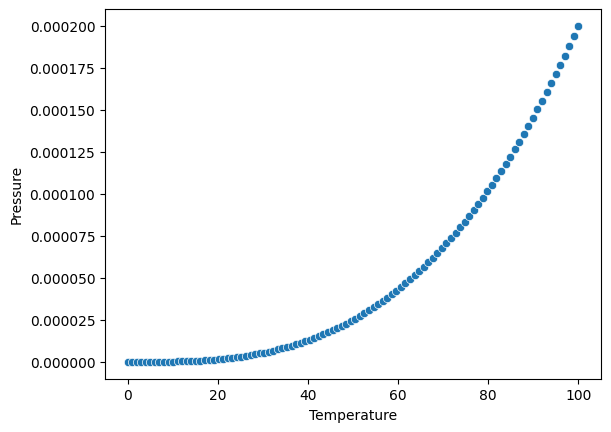

In [64]:
sns.scatterplot(x = "Temperature", y = "Pressure", data = data)

In [65]:
x = data[['Temperature']]
y = data[['Pressure']]

In [66]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [68]:
poly_lr_model = LinearRegression()
poly_lr_model.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [69]:
y_pred = poly_lr_model.predict(x_test_poly)
y_pred[:5]

array([[1.20924362e-04],
       [3.14230379e-05],
       [7.52425366e-05],
       [1.70445572e-05],
       [1.55281578e-05]])

In [70]:
y_test[:5]

,Pressure
83,0.000118
53,0.000031
70,0.000071
45,0.000019
44,0.000018


In [71]:
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

RMSE: 4.2888689864178e-06
R²: 0.9918312022686296


In [72]:
X_range = np.linspace(x.min(), x.max(), 100)
X_range_poly = poly.transform(X_range)
y_range_pred = poly_lr_model.predict(X_range_poly)

/home/haze/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


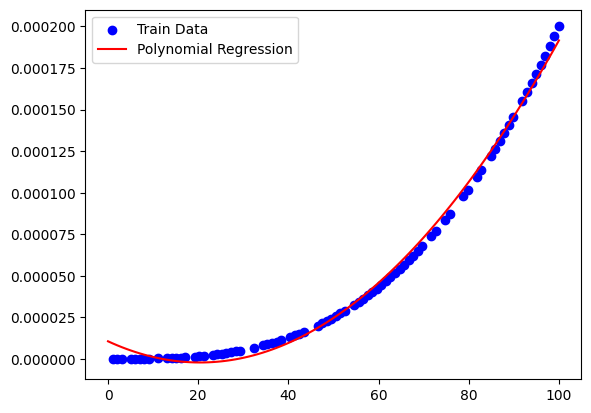

In [73]:
plt.scatter(x_train, y_train, color='blue', label='Train Data')
plt.plot(X_range, y_range_pred, color='red', label='Polynomial Regression')
plt.legend()
plt.show()

In [74]:
mpg_data = pd.read_csv('Resources/auto_mpg_cleaned.csv')
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


mpg_data.info()

In [75]:
mpg_data['model year'].value_counts()

model year
73    40
78    36
76    34
82    30
75    30
79    29
70    29
72    28
77    28
81    28
71    27
80    27
74    26
Name: count, dtype: int64

In [76]:
mpg_data['origin'].value_counts()

origin
1    245
3     79
2     68
Name: count, dtype: int64

In [77]:
mpg_data.drop("car name", axis=1, inplace=True)
mpg_data.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


In [78]:
M = mpg_data.drop(columns=['mpg'], axis=1)
N = (mpg_data['mpg'] > mpg_data['mpg'].median()).astype(int)

In [79]:
x_train, x_test, y_train, y_test = train_test_split(M, N, test_size=0.2, random_state=42)

In [80]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [81]:
mpg_logistic_regression_model = LinearRegression()
mpg_logistic_regression_model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
y_pred_lor = mpg_logistic_regression_model.predict(x_test_scaled)
y_pred_lor[:20]

array([ 0.68957425,  0.80790324,  1.03851973,  0.66960989,  0.83219531,
        0.90214682, -0.28706983,  0.91275606,  0.29044436,  0.76950335,
       -0.04811402,  0.53612729,  0.05082423,  0.8622031 ,  0.45487776,
        0.89363844,  0.29200983,  1.02141927,  0.74206523,  0.90476313])

In [83]:
y_test[:20]

78     1
274    0
246    1
55     1
387    1
203    1
42     0
233    1
150    0
116    1
9      0
208    0
287    0
165    1
275    0
362    1
124    0
351    1
294    1
332    1
Name: mpg, dtype: int64

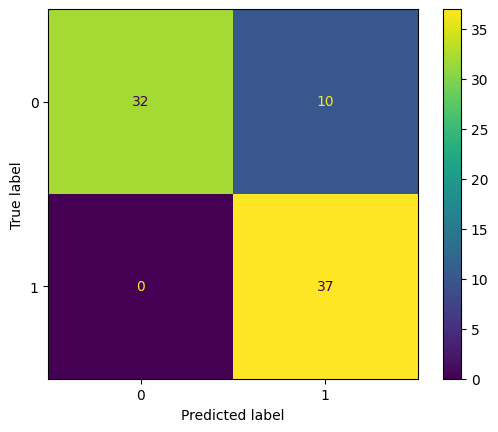

In [84]:
#confusion matrix 
#x axis actual y axis predicted
y_pred_lor_binary = (y_pred_lor >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_lor_binary)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.show()


In [85]:
N.value_counts()


mpg
0    196
1    196
Name: count, dtype: int64

In [86]:
print(f"Accuracy of the model: {accuracy_score(y_test, y_pred_lor_binary)*100:.2f}%")
print(f"Precision of the model: {precision_score(y_test, y_pred_lor_binary)*100:.2f}%")
print(f"Recall of the model: {recall_score(y_test, y_pred_lor_binary)*100:.2f}%")

Accuracy of the model: 87.34%
Precision of the model: 78.72%
Recall of the model: 100.00%


In [88]:
print(classification_report(y_test, y_pred_lor_binary))

              precision    recall  f1-score   support

           0       1.00      0.76      0.86        42
           1       0.79      1.00      0.88        37

    accuracy                           0.87        79
   macro avg       0.89      0.88      0.87        79
weighted avg       0.90      0.87      0.87        79



In [91]:
conf = confusion_matrix(y_test, y_pred_lor_binary)
conf

array([[32, 10],
       [ 0, 37]])

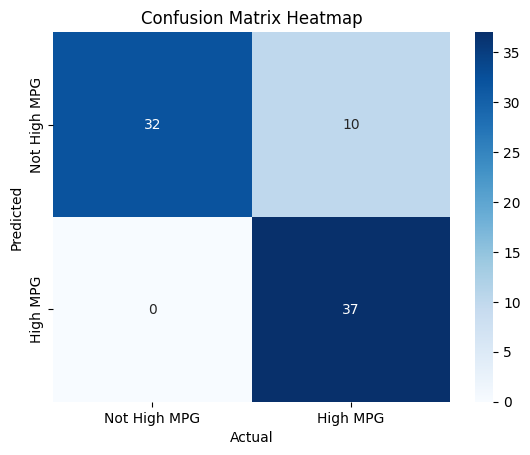

In [103]:
sns.heatmap(conf,fmt = 'd', annot=True, xticklabels=["Not High MPG", "High MPG"], yticklabels=["Not High MPG", "High MPG"], cmap="Blues")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [102]:
jb.dump(mpg_logistic_regression_model, 'mpg_logistic_regression_model.pkl')

['mpg_logistic_regression_model.pkl']

In [104]:
#dump scalar model
jb.dump(scaler, 'mpg_scaler.pkl')

['mpg_scaler.pkl']

In [107]:
#load the model
model = jb.load('mpg_logistic_regression_model.pkl')
scale = jb.load('mpg_scaler.pkl')

In [113]:
cyl = int(input("Enter the number of cylinders(2 to 10): "))
dsp = float(input("Enter displacement(60 to 550): "))
hp = float(input("Enter horsepower(40 to 300): "))
wt = int(input("Enter weight(1600 to 5200): "))
acc = int(input("Enter acceleration(2 to 26): "))
mody = int(input("Enter model year(70 to 98): "))
org = int(input("Enter origin(1 for USA, 2 for Japan, 3 for Europe): "))

#convert it numpy array
new_data = np.array([[cyl, dsp, hp, wt, acc, mody, org]])

#scale the data
new_data_scaled = scaler.transform(new_data)

#prediction
prediction = model.predict(new_data_scaled)
print(prediction)

if prediction[0] == 1:
    print("The car is Efficient.")
else:
    print("The car is Not Efficient.")


[0.81081533]
The car is Not Efficient.
0
The car is not efficient.


/home/haze/.local/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [116]:
#Gausian Naive Bayes
mpg_model_nb = GaussianNB()
mpg_model_nb.fit(x_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [118]:
y_pred_nb = mpg_model_nb.predict(x_test_scaled)
y_pred_nb[:10]

array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [119]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87        42
           1       0.80      0.97      0.88        37

    accuracy                           0.87        79
   macro avg       0.89      0.88      0.87        79
weighted avg       0.89      0.87      0.87        79



In [121]:
mpg_model_knn = KNeighborsClassifier(n_neighbors=11)
mpg_model_knn.fit(x_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [123]:
y_pred_knn = mpg_model_knn.predict(x_test_scaled)
y_pred_knn[:10]


array([1, 1, 1, 1, 1, 1, 0, 1, 0, 1])

In [124]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.97      0.79      0.87        42
           1       0.80      0.97      0.88        37

    accuracy                           0.87        79
   macro avg       0.89      0.88      0.87        79
weighted avg       0.89      0.87      0.87        79

